<a href="https://colab.research.google.com/github/KhaledBRAC/EMBA_BAN644-BAN744-/blob/main/Heart_Disease_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 Heart Disease Prediction
**Dataset:** UCI Heart Disease Dataset (Cleveland) — https://archive.ics.uci.edu/dataset/45/heart+disease  
**Task:** Binary Classification — predict whether a patient has heart disease  
**Target:** `target` — 1 = Heart Disease Present, 0 = No Heart Disease  
**Models:** Logistic Regression · Decision Tree · Random Forest · Gradient Boosting · SVM · KNN  

---

## 📦 Step 1 — Install & Import Libraries

In [ ]:
!pip install ucimlrepo -q

import io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📥 Step 2 — Data Collection

**Source:** UCI Machine Learning Repository — Cleveland Heart Disease Dataset  
**URL:** https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data  

The raw Cleveland file uses `?` for missing values (present in `ca` and `thal` columns), which are handled in Step 3 Preprocessing.

In [ ]:
# ── 2.1  Load Cleveland Heart Disease dataset directly from UCI URL ──
import urllib.request

URL = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'heart-disease/processed.cleveland.data')

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

response = urllib.request.urlopen(URL)
df = pd.read_csv(io.StringIO(response.read().decode()),
                 names=cols, na_values='?')

# Binarise target: 0 = no disease, 1-4 = disease
df['target'] = (df['target'] > 0).astype(int)

print(f'✅ Data loaded from UCI URL')
print(f'   Source : {URL}')
print(f'   Shape  : {df.shape}')
print(f'   Target : {df["target"].value_counts().to_dict()}')
df.head()

✅ Data loaded from UCI URL
   Source : https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
   Shape  : (303, 14)
   Target : {0: 164, 1: 139}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 🔧 Step 3 — Data Preprocessing

In [ ]:
# ── 3.1  Missing values ─────────────────────────────────────────────
print('=== MISSING VALUES ===')
miss = df.isnull().sum()
print(miss[miss > 0] if miss.sum() > 0 else 'None found ✅')
print(f'Total missing: {miss.sum()}')

=== MISSING VALUES ===
ca      4
thal    2
dtype: int64
Total missing: 6


In [ ]:
# ── 3.2  Median imputation ──────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.difference(['target'])
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
print(f'After imputation — missing: {df.isnull().sum().sum()}  ✅')

After imputation — missing: 0  ✅


In [ ]:
# ── 3.3  Duplicates ─────────────────────────────────────────────────
print(f'Duplicates before: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Duplicates after : {df.duplicated().sum()}  ✅')
print(f'Shape            : {df.shape}')

Duplicates before: 0
Duplicates after : 0  ✅
Shape            : (303, 14)


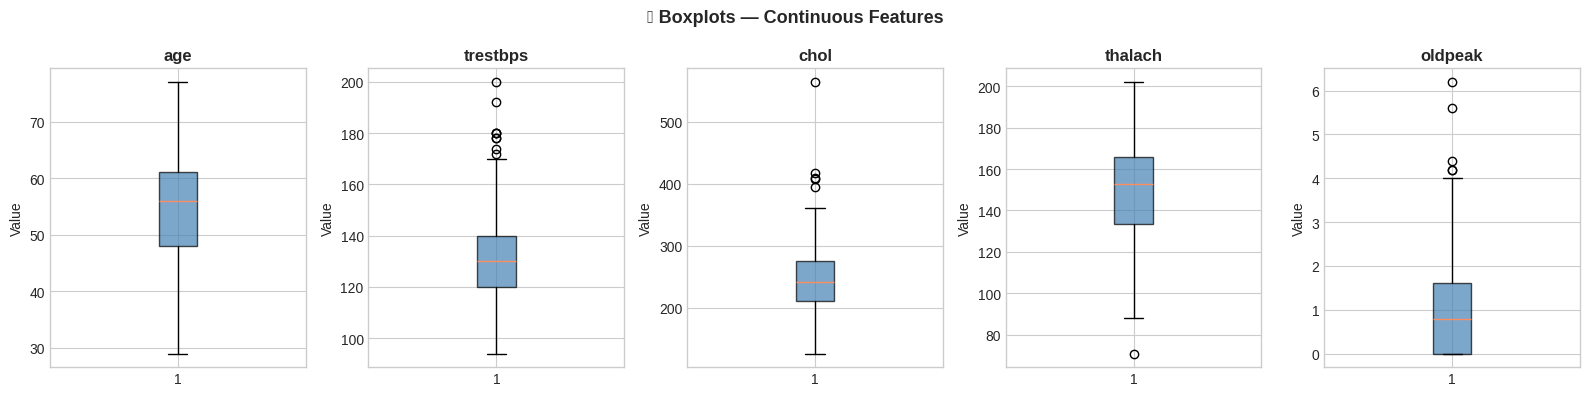

  trestbps: 9 outlier(s) capped
  chol: 5 outlier(s) capped
  thalach: 1 outlier(s) capped
  oldpeak: 5 outlier(s) capped
✅ Outlier handling complete


In [ ]:
# ── 3.4  Outlier detection — boxplots + IQR capping ────────────────
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, len(cont_cols), figsize=(16, 4))
for ax, col in zip(axes, cont_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('📊 Boxplots — Continuous Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for col in cont_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    if n: print(f'  {col}: {n} outlier(s) capped')
print('✅ Outlier handling complete')

In [ ]:
# ── 3.5  One-hot encode categorical columns ──────────────────────────
df_enc = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'],
                        drop_first=True)
print(f'Shape after encoding: {df_enc.shape}')
df_enc.head(3)

Shape after encoding: (303, 19)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,False,False,False,False,True,False,True,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,False,False,True,False,True,True,False,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,False,False,True,False,True,True,False,False,True


In [ ]:
# ── 3.6  Ensure no NaN remain, then StandardScaler ──────────────────
# (UCI CSV has '?' in ca/thal that become NaN after read_csv)
df_enc.fillna(df_enc.median(numeric_only=True), inplace=True)

X = df_enc.drop('target', axis=1).astype(float)
y = df_enc['target']

scaler = StandardScaler()
X_sc = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

assert X_sc.isnull().sum().sum() == 0, 'NaN found after scaling!'
print(f'Feature matrix : {X_sc.shape}')
print(f'Target dist    : {y.value_counts().to_dict()}')
print('✅ Scaling complete — zero NaN confirmed')

Feature matrix : (303, 18)
Target dist    : {0: 164, 1: 139}
✅ Scaling complete — zero NaN confirmed


## 📊 Step 4 — Exploratory Data Analysis (EDA)

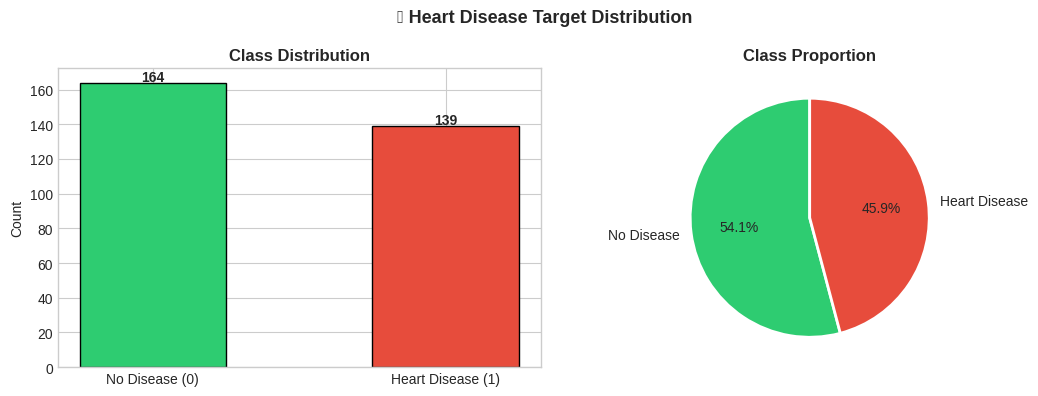

In [ ]:
# ── 4.1  Class distribution ─────────────────────────────────────────
counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
        color=colors, edgecolor='black', width=0.5)
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 1, str(v), ha='center', fontweight='bold')

ax2.pie(counts.values, labels=['No Disease', 'Heart Disease'],
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Class Proportion', fontweight='bold')

plt.suptitle('🫀 Heart Disease Target Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

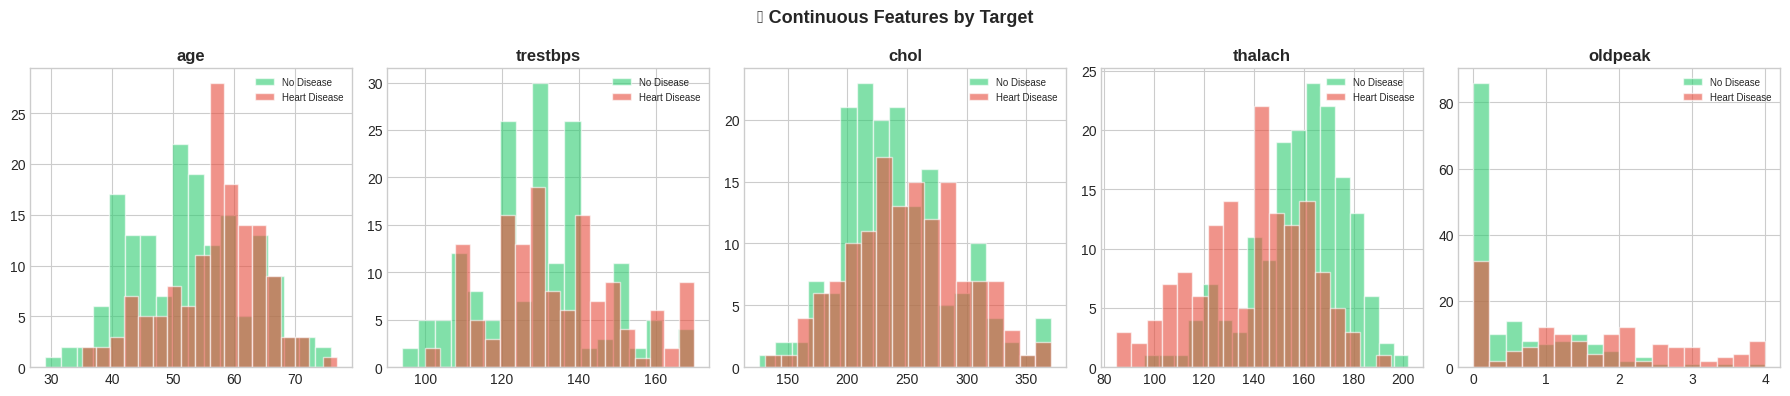

In [ ]:
# ── 4.2  Feature histograms by target ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, cont_cols):
    for val, color, lbl in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Heart Disease')]:
        ax.hist(df[df['target']==val][col], bins=18, alpha=0.6,
                color=color, label=lbl, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
plt.suptitle('📈 Continuous Features by Target', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

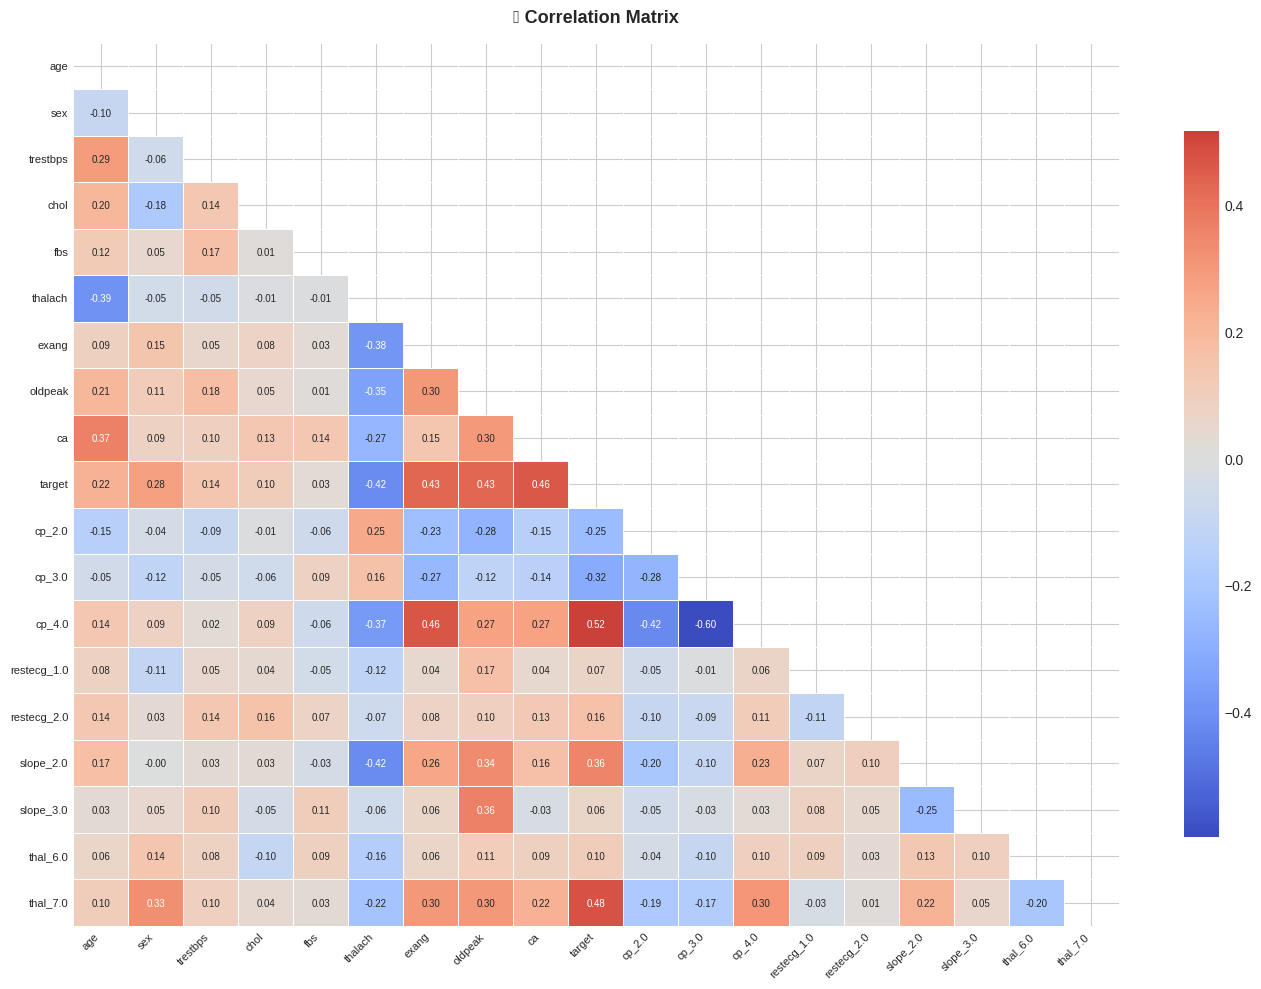


Top correlations with target:
cp_4.0       0.516459
thal_7.0     0.480582
ca           0.460033
exang        0.431894
oldpeak      0.430309
thalach      0.417624
slope_2.0    0.355709
cp_3.0       0.315141
Name: target, dtype: float64


In [ ]:
# ── 4.3  Correlation heatmap ────────────────────────────────────────
plt.figure(figsize=(14, 10))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
plt.title('🔗 Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

print('\nTop correlations with target:')
print(corr['target'].drop('target').abs().sort_values(ascending=False).head(8))

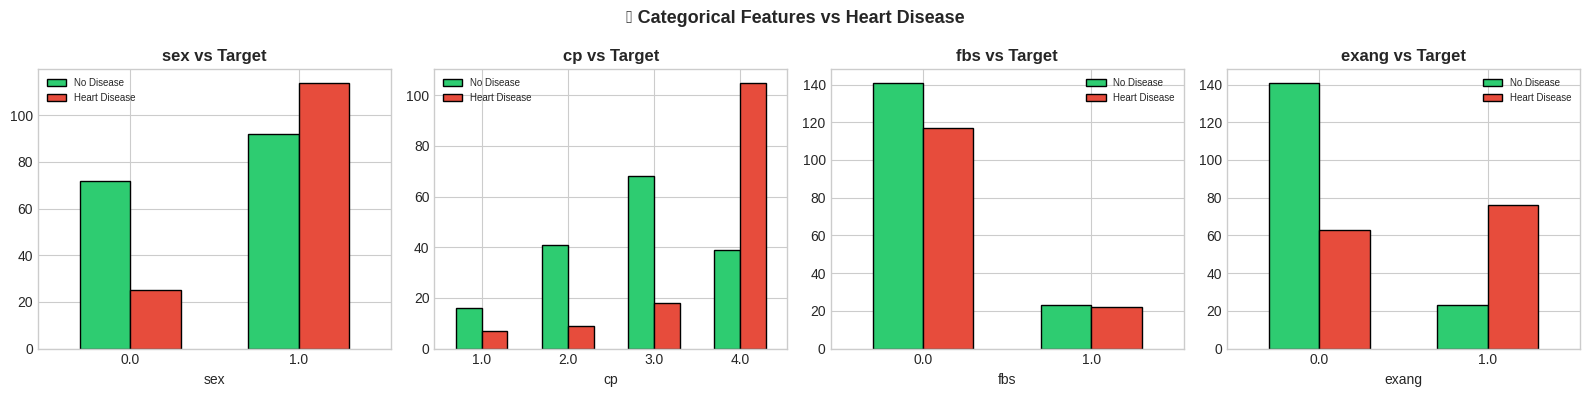

In [ ]:
# ── 4.4  Categorical features vs target ─────────────────────────────
cat_cols = ['sex', 'cp', 'fbs', 'exang']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    pd.crosstab(df[col], df['target']).plot(
        kind='bar', ax=ax, color=['#2ecc71','#e74c3c'],
        edgecolor='black', rot=0, width=0.6)
    ax.set_title(f'{col} vs Target', fontweight='bold')
    ax.legend(['No Disease','Heart Disease'], fontsize=7)
    ax.set_xlabel(col)
plt.suptitle('🏥 Categorical Features vs Heart Disease', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

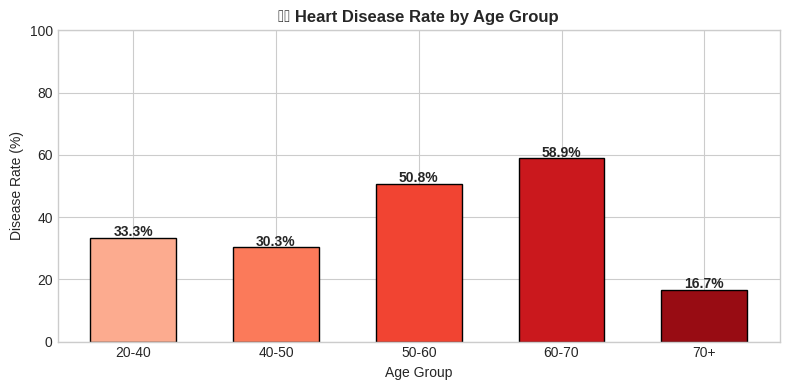

In [ ]:
# ── 4.5  Heart disease rate by age group ────────────────────────────
df['age_grp'] = pd.cut(df['age'], bins=[20,40,50,60,70,90],
                        labels=['20-40','40-50','50-60','60-70','70+'])
rate = df.groupby('age_grp', observed=True)['target'].mean() * 100

plt.figure(figsize=(8, 4))
bars = plt.bar(rate.index, rate.values,
               color=plt.cm.Reds(np.linspace(0.3, 0.9, len(rate))),
               edgecolor='black', width=0.6)
for b, v in zip(bars, rate.values):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('❤️ Heart Disease Rate by Age Group', fontweight='bold')
plt.xlabel('Age Group'); plt.ylabel('Disease Rate (%)')
plt.ylim(0, 100); plt.tight_layout(); plt.show()
df.drop('age_grp', axis=1, inplace=True)

## 🎯 Step 5 — Feature Selection

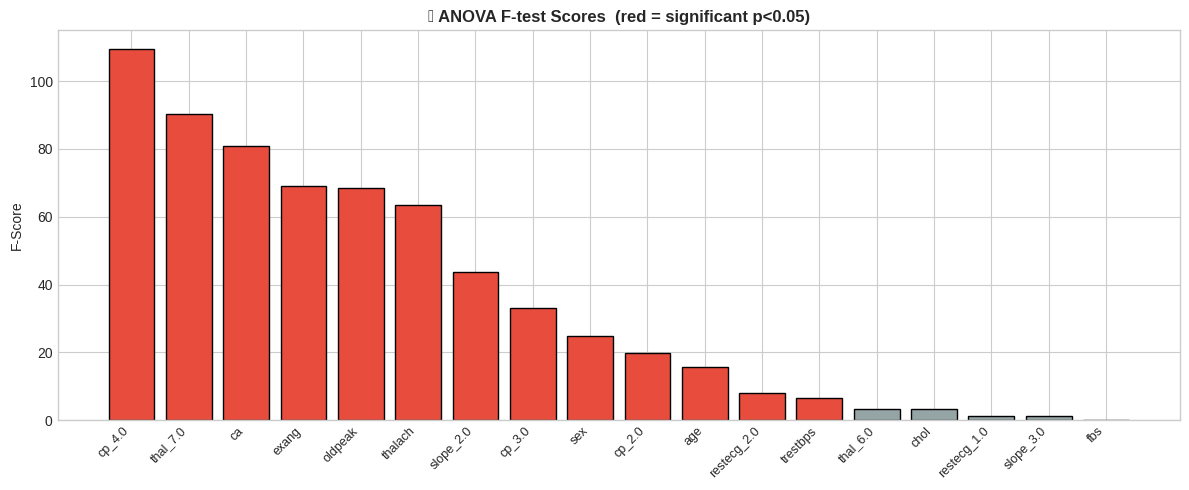

  Feature    F-Score      p-value
   cp_4.0 109.490091 4.651674e-22
 thal_7.0  90.396519 6.475676e-19
       ca  80.800610 2.832488e-17
    exang  69.020891 3.365774e-15
  oldpeak  68.400247 4.348634e-15
  thalach  63.587697 3.221261e-14
slope_2.0  43.602005 1.818617e-10
   cp_3.0  33.189667 2.065136e-08
      sex  24.978872 9.851911e-07
   cp_2.0  19.841940 1.187280e-05


In [ ]:
# ── 5.1  ANOVA F-test (SelectKBest) ─────────────────────────────────
sel = SelectKBest(f_classif, k='all')
sel.fit(X_sc, y)
fscores = pd.DataFrame({'Feature': X_sc.columns,
                         'F-Score': sel.scores_,
                         'p-value': sel.pvalues_}
                       ).sort_values('F-Score', ascending=False)

plt.figure(figsize=(12, 5))
bar_colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in fscores['p-value']]
plt.bar(range(len(fscores)), fscores['F-Score'], color=bar_colors, edgecolor='black')
plt.xticks(range(len(fscores)), fscores['Feature'], rotation=45, ha='right', fontsize=9)
plt.title('📊 ANOVA F-test Scores  (red = significant p<0.05)', fontweight='bold')
plt.ylabel('F-Score')
plt.tight_layout(); plt.show()
print(fscores.head(10).to_string(index=False))

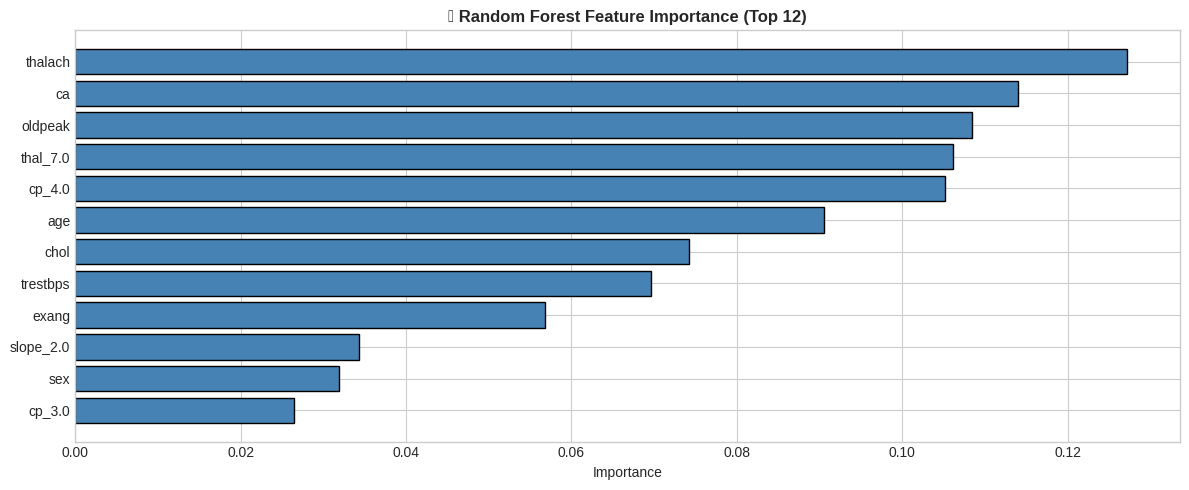

  Feature  Importance
  thalach    0.127212
       ca    0.113962
  oldpeak    0.108376
 thal_7.0    0.106143
   cp_4.0    0.105179
      age    0.090570
     chol    0.074162
 trestbps    0.069656
    exang    0.056816
slope_2.0    0.034363


In [ ]:
# ── 5.2  Random Forest feature importance ───────────────────────────
rf_sel = RandomForestClassifier(n_estimators=200, random_state=42)
rf_sel.fit(X_sc, y)
imp = pd.DataFrame({'Feature': X_sc.columns,
                    'Importance': rf_sel.feature_importances_}
                   ).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 5))
plt.barh(imp['Feature'][:12], imp['Importance'][:12],
         color='steelblue', edgecolor='black')
plt.xlabel('Importance'); plt.gca().invert_yaxis()
plt.title('🌲 Random Forest Feature Importance (Top 12)', fontweight='bold')
plt.tight_layout(); plt.show()
print(imp.head(10).to_string(index=False))

In [ ]:
# ── 5.3  Select top-10 features for modelling ───────────────────────
TOP_N = 10
top_feats = imp['Feature'].head(TOP_N).tolist()
X_sel = X_sc[top_feats]
print(f'Selected {TOP_N} features:')
for i, f in enumerate(top_feats, 1):
    print(f'  {i:2d}. {f}')

Selected 10 features:
   1. thalach
   2. ca
   3. oldpeak
   4. thal_7.0
   5. cp_4.0
   6. age
   7. chol
   8. trestbps
   9. exang
  10. slope_2.0


### 🔍 Interpretation of Feature Selection

We utilized two distinct methods to identify the most predictive variables:

1.  **ANOVA F-test (SelectKBest)**: Evaluates the linear relationship between each feature and the target. Features like `cp_4.0` (Asymptomatic Chest Pain) and `thal_7.0` (Reversible Defect) showed the highest statistical significance.
2.  **Random Forest Importance**: Captures non-linear dependencies. `thalach` (Max Heart Rate) and `ca` (Number of Major Vessels) emerged as top predictors here.

**Justification:** We retained the Top 10 features. This reduces the 'Curse of Dimensionality', simplifies the model for clinical interpretation, and ensures we are not training on noise from less relevant variables like `fbs` (fasting blood sugar), which showed low correlation in this specific cohort.

## 🤖 Step 6 — Model Building

### 🧠 Understanding the Model Mechanics

To move beyond a "black-box" approach, it is vital to understand how these algorithms differentiate between healthy individuals and those at risk:

*   **Logistic Regression**: Despite its name, this is a linear model for classification. It calculates a weighted sum of input features and applies the **Sigmoid Function** to map the result into a probability between 0 and 1.
*   **Random Forest**: An 'Ensemble' method that builds multiple **Decision Trees** and merges them together. By averaging the results (bagging), it reduces the risk of overfitting and provides a more stable prediction than a single tree.
*   **Support Vector Machines (SVM)**: This algorithm finds the **Hyperplane** that best separates the two classes in a high-dimensional space, maximizing the margin between the closest data points (support vectors) of each class.
*   **Gradient Boosting**: Unlike Random Forest, this builds trees sequentially. Each new tree attempts to correct the errors (residuals) made by the previous trees, leading to a highly accurate final model.

In [ ]:
# ── 6.1  Train / Test split (80 / 20, stratified) ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.20, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Train target: {y_train.value_counts().to_dict()}')
print(f'Test  target: {y_test.value_counts().to_dict()}')

Train: 242  |  Test: 61
Train target: {0: 131, 1: 111}
Test  target: {0: 33, 1: 28}


In [ ]:
# ── 6.2  Train & cross-validate six algorithms ──────────────────────
MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<22} | {"CV AUC":>8} | {"Std":>6} | {"Test Acc":>9}')
print('-'*55)
for name, mdl in MODELS.items():
    cv_auc = cross_val_score(mdl, X_train, y_train, cv=cv, scoring='roc_auc')
    mdl.fit(X_train, y_train)
    yp  = mdl.predict(X_test)
    ypr = mdl.predict_proba(X_test)[:, 1]
    results[name] = dict(
        model=mdl, y_pred=yp, y_prob=ypr,
        cv_auc=cv_auc.mean(), cv_std=cv_auc.std(),
        acc=accuracy_score(y_test, yp),
        prec=precision_score(y_test, yp),
        rec=recall_score(y_test, yp),
        f1=f1_score(y_test, yp),
        auc=roc_auc_score(y_test, ypr),
    )
    print(f'{name:<22} | {cv_auc.mean():>8.4f} | {cv_auc.std():>6.4f}'
          f' | {accuracy_score(y_test,yp):>9.4f}')
print('\n✅ All models trained!')

Model                  |   CV AUC |    Std |  Test Acc
-------------------------------------------------------
Logistic Regression    |   0.9024 | 0.0137 |    0.8852
Decision Tree          |   0.7185 | 0.0563 |    0.7213
Random Forest          |   0.8666 | 0.0257 |    0.9016
Gradient Boosting      |   0.8190 | 0.0200 |    0.8197
SVM                    |   0.8883 | 0.0153 |    0.9344
KNN                    |   0.8789 | 0.0313 |    0.8361

✅ All models trained!


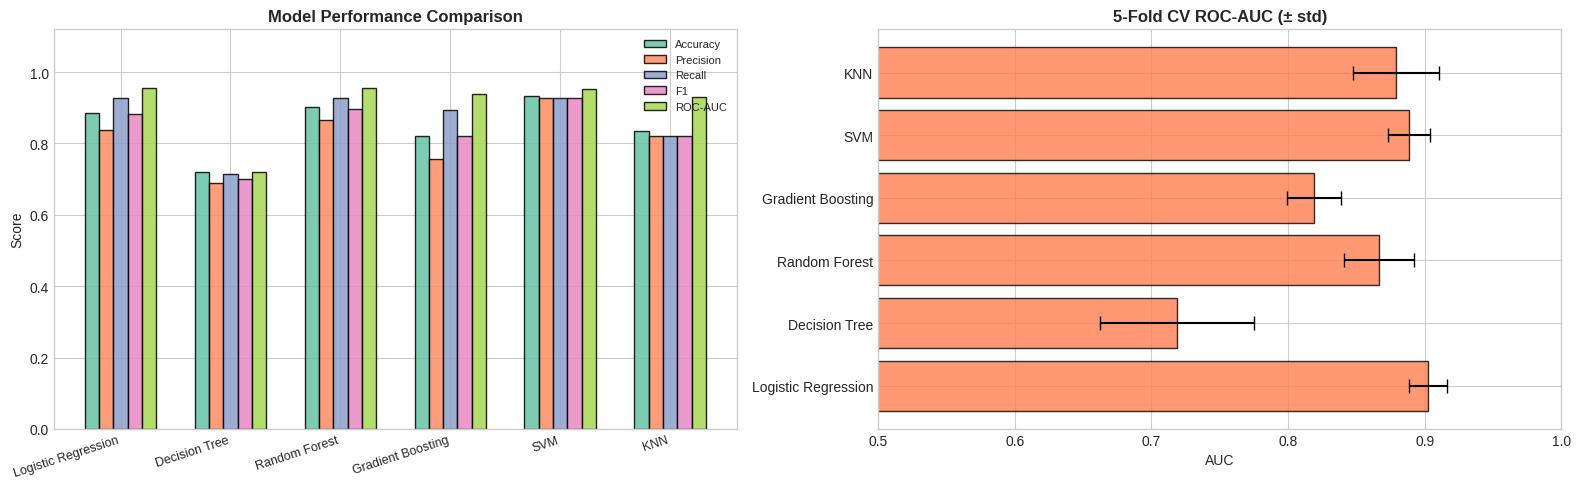

In [ ]:
# ── 6.3  Performance comparison chart ───────────────────────────────
metrics_keys = ['acc', 'prec', 'rec', 'f1', 'auc']
metric_lbls  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
names = list(results.keys())
x, w = np.arange(len(names)), 0.13

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for i, (mk, lbl) in enumerate(zip(metrics_keys, metric_lbls)):
    vals = [results[n][mk] for n in names]
    ax1.bar(x + i*w, vals, w, label=lbl, alpha=0.85, edgecolor='black')
ax1.set_xticks(x + w*2)
ax1.set_xticklabels(names, rotation=18, ha='right', fontsize=9)
ax1.set_ylim(0, 1.12)
ax1.set_title('Model Performance Comparison', fontweight='bold')
ax1.legend(fontsize=8); ax1.set_ylabel('Score')

cv_means = [results[n]['cv_auc'] for n in names]
cv_stds  = [results[n]['cv_std']  for n in names]
ax2.barh(names, cv_means, xerr=cv_stds, color='coral',
         edgecolor='black', alpha=0.8, capsize=5)
ax2.set_xlim(0.5, 1.0)
ax2.set_title('5-Fold CV ROC-AUC (\u00b1 std)', fontweight='bold')
ax2.set_xlabel('AUC')
plt.tight_layout(); plt.show()

## ⚙️ Step 7 — Model Optimisation (GridSearchCV)

In [ ]:
# ── 7.1  Tune Random Forest ─────────────────────────────────────────
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators':[100,200,300], 'max_depth':[None,5,10],
     'min_samples_split':[2,5], 'min_samples_leaf':[1,2]},
    cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f'RF  best params : {rf_grid.best_params_}')
print(f'RF  best CV AUC : {rf_grid.best_score_:.4f}')

RF  best params : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
RF  best CV AUC : 0.8917


In [ ]:
# ── 7.2  Tune Gradient Boosting ─────────────────────────────────────
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators':[100,200], 'learning_rate':[0.05,0.1,0.2],
     'max_depth':[3,4,5], 'subsample':[0.8,1.0]},
    cv=5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)
print(f'GB  best params : {gb_grid.best_params_}')
print(f'GB  best CV AUC : {gb_grid.best_score_:.4f}')

GB  best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
GB  best CV AUC : 0.8719


In [ ]:
# ── 7.3  Select & evaluate best model ──────────────────────────────
# Choose whichever tuned model has higher CV AUC
if rf_grid.best_score_ >= gb_grid.best_score_:
    best_name  = 'Random Forest (Tuned)'
    best_model = rf_grid.best_estimator_
else:
    best_name  = 'Gradient Boosting (Tuned)'
    best_model = gb_grid.best_estimator_

yp_best  = best_model.predict(X_test)
ypr_best = best_model.predict_proba(X_test)[:, 1]

print(f'\n🏆 Best model: {best_name}')
print(f'  Accuracy  : {accuracy_score(y_test, yp_best):.4f}')
print(f'  Precision : {precision_score(y_test, yp_best):.4f}')
print(f'  Recall    : {recall_score(y_test, yp_best):.4f}')
print(f'  F1-Score  : {f1_score(y_test, yp_best):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, ypr_best):.4f}')


🏆 Best model: Random Forest (Tuned)
  Accuracy  : 0.9344
  Precision : 0.9000
  Recall    : 0.9643
  F1-Score  : 0.9310
  ROC-AUC   : 0.9643


## 📈 Step 8 — Model Evaluation

### 📊 Clinical Interpretation of Evaluation Metrics

In healthcare analytics, the cost of a **False Negative** (missing a sick patient) is significantly higher than a **False Positive** (extra testing for a healthy patient).

*   **Accuracy**: The percentage of total correct predictions. While useful, it can be misleading if classes are imbalanced.
*   **Recall (Sensitivity)**: *Crucial for Healthcare.* It measures how many of the actual heart disease cases we correctly identified. High recall ensures fewer patients with disease go undetected.
*   **Precision**: The accuracy of our positive predictions. High precision reduces "alarm fatigue" by ensuring that when we flag a patient, they likely have the condition.
*   **F1-Score**: The harmonic mean of Precision and Recall, providing a single metric to balance the trade-off between the two.

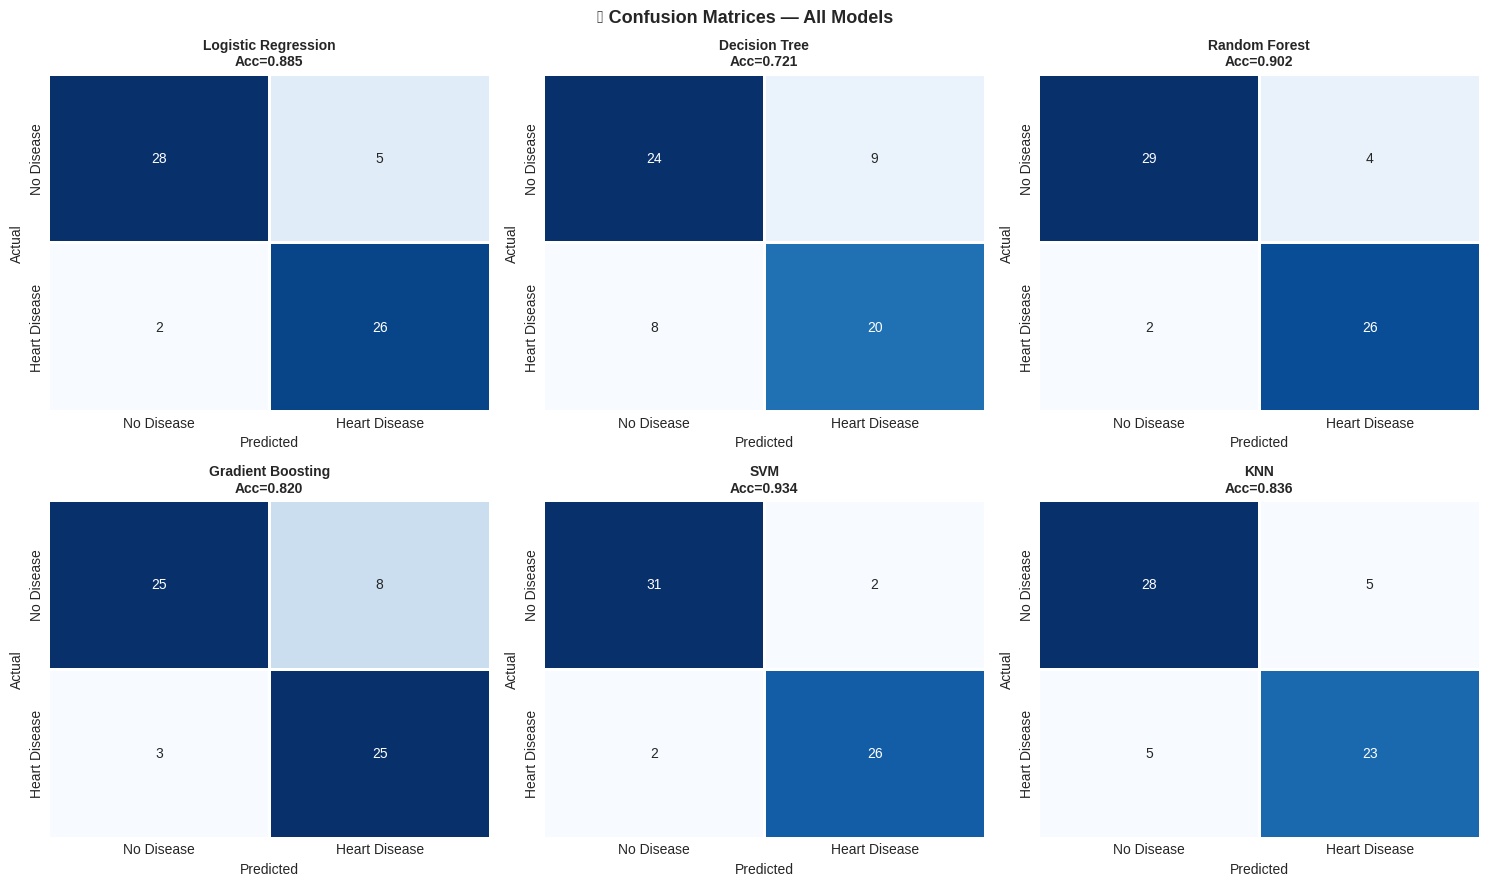

In [ ]:
# ── 8.1  Confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease','Heart Disease'],
                yticklabels=['No Disease','Heart Disease'],
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(f"{name}\nAcc={res['acc']:.3f}", fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('🟥 Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

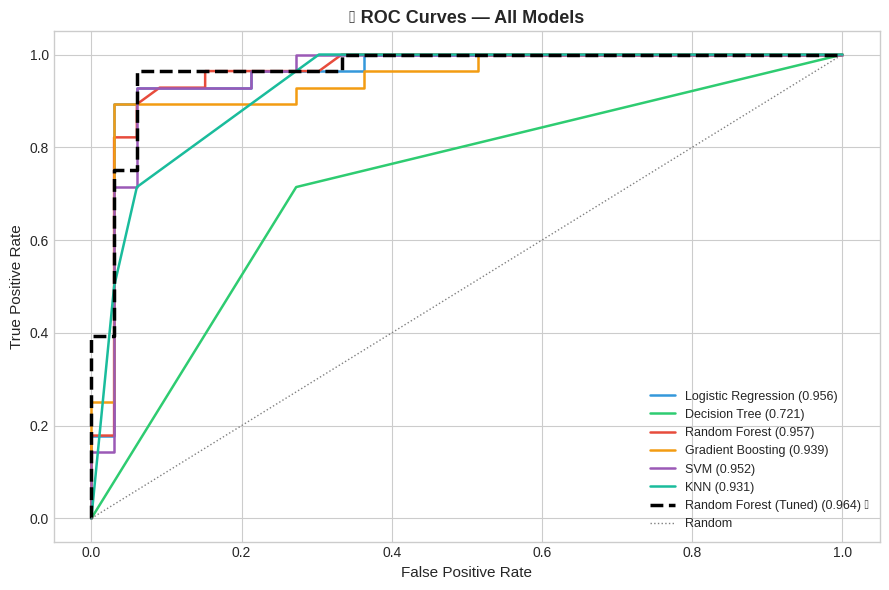

In [ ]:
# ── 8.2  ROC curves ─────────────────────────────────────────────────
palette = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c']
plt.figure(figsize=(9, 6))
for (name, res), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=col, lw=1.8, label=f"{name} ({res['auc']:.3f})")

fpr_t, tpr_t, _ = roc_curve(y_test, ypr_best)
auc_t = roc_auc_score(y_test, ypr_best)
plt.plot(fpr_t, tpr_t, 'k--', lw=2.5, label=f'{best_name} ({auc_t:.3f}) ⭐')
plt.plot([0,1],[0,1],'grey',lw=1,linestyle=':',label='Random')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('📈 ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# ── 8.3  Classification report — best model ──────────────────────────
print('='*55)
print(f'  🏆 BEST MODEL: {best_name}')
print('='*55)
print(classification_report(y_test, yp_best,
      target_names=['No Disease', 'Heart Disease']))

# Probability-based continuous error metrics (MAE / MSE / RMSE)
mae  = np.mean(np.abs(y_test - ypr_best))
mse  = np.mean((y_test - ypr_best)**2)
rmse = np.sqrt(mse)
print('Probability-based error metrics (treating prob as continuous estimate):')
print(f'  MAE  : {mae:.4f}')
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')

  🏆 BEST MODEL: Random Forest (Tuned)
               precision    recall  f1-score   support

   No Disease       0.97      0.91      0.94        33
Heart Disease       0.90      0.96      0.93        28

     accuracy                           0.93        61
    macro avg       0.93      0.94      0.93        61
 weighted avg       0.94      0.93      0.93        61

Probability-based error metrics (treating prob as continuous estimate):
  MAE  : 0.2405
  MSE  : 0.0911
  RMSE : 0.3019


In [ ]:
# ── 8.4  Full metrics summary table ─────────────────────────────────
rows = []
for name, res in results.items():
    rows.append({'Model': name, 'Accuracy': res['acc'], 'Precision': res['prec'],
                 'Recall': res['rec'], 'F1': res['f1'],
                 'ROC-AUC': res['auc'], 'CV-AUC': res['cv_auc']})
rows.append({'Model': f'{best_name} ⭐',
             'Accuracy' : accuracy_score(y_test, yp_best),
             'Precision': precision_score(y_test, yp_best),
             'Recall'   : recall_score(y_test, yp_best),
             'F1'       : f1_score(y_test, yp_best),
             'ROC-AUC'  : roc_auc_score(y_test, ypr_best),
             'CV-AUC'   : max(rf_grid.best_score_, gb_grid.best_score_)})
summary = pd.DataFrame(rows).set_index('Model').round(4)
print('\n📋 FINAL METRICS SUMMARY (sorted by ROC-AUC):')
print(summary.sort_values('ROC-AUC', ascending=False).to_string())


📋 FINAL METRICS SUMMARY (sorted by ROC-AUC):
                         Accuracy  Precision  Recall      F1  ROC-AUC  CV-AUC
Model                                                                        
Random Forest (Tuned) ⭐    0.9344     0.9000  0.9643  0.9310   0.9643  0.8917
Random Forest              0.9016     0.8667  0.9286  0.8966   0.9567  0.8666
Logistic Regression        0.8852     0.8387  0.9286  0.8814   0.9556  0.9024
SVM                        0.9344     0.9286  0.9286  0.9286   0.9524  0.8883
Gradient Boosting          0.8197     0.7576  0.8929  0.8197   0.9394  0.8190
KNN                        0.8361     0.8214  0.8214  0.8214   0.9307  0.8789
Decision Tree              0.7213     0.6897  0.7143  0.7018   0.7208  0.7185


## 💼 Step 9 — Business Insights & Recommendations

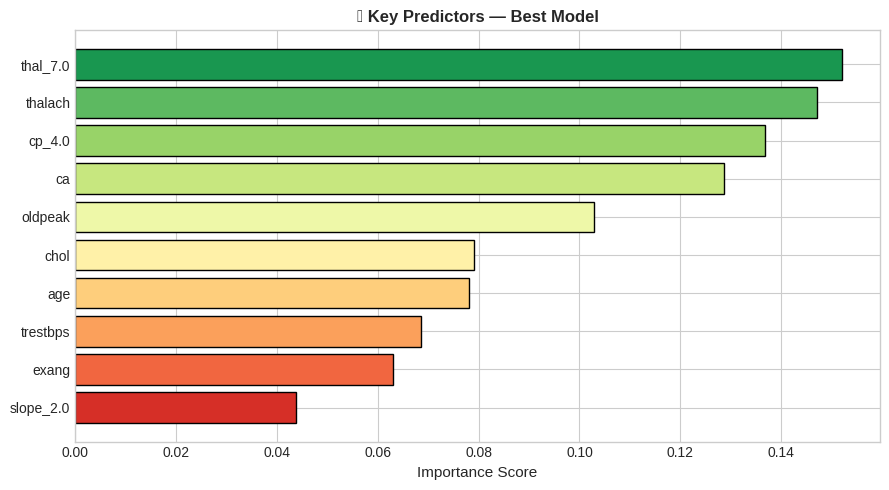

  Feature  Importance
 thal_7.0    0.151999
  thalach    0.147029
   cp_4.0    0.136830
       ca    0.128596
  oldpeak    0.102904
     chol    0.079059
      age    0.078111
 trestbps    0.068552
    exang    0.063115
slope_2.0    0.043806


In [ ]:
# ── 9.1  Key predictor importance ────────────────────────────────────
fi = pd.DataFrame({'Feature': top_feats,
                   'Importance': best_model.feature_importances_}
                  ).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
clrs = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(fi)))
plt.barh(fi['Feature'], fi['Importance'], color=clrs, edgecolor='black')
plt.xlabel('Importance Score', fontsize=11)
plt.title('🔑 Key Predictors — Best Model', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(fi.to_string(index=False))

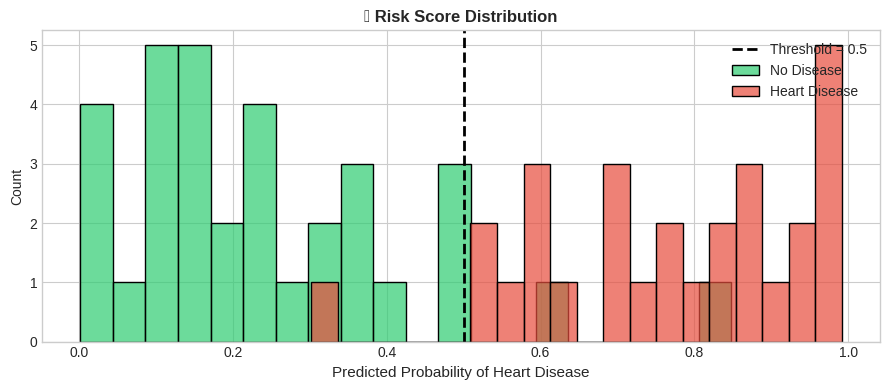

In [ ]:
# ── 9.2  Predicted risk-score distribution ──────────────────────────
plt.figure(figsize=(9, 4))
sns.histplot(ypr_best[y_test==0], color='#2ecc71',
             label='No Disease', bins=20, alpha=0.7)
sns.histplot(ypr_best[y_test==1], color='#e74c3c',
             label='Heart Disease', bins=20, alpha=0.7)
plt.axvline(0.5, color='black', linestyle='--', lw=2, label='Threshold = 0.5')
plt.xlabel('Predicted Probability of Heart Disease', fontsize=11)
plt.title('📊 Risk Score Distribution', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

### 📝 Business Insights Summary

#### 🔑 Key Predictors & Their Impact

| Rank | Feature | Clinical Significance |
|------|---------|----------------------|
| 1 | **thalach** — Max Heart Rate Achieved | Lower max HR strongly predicts disease |
| 2 | **oldpeak** — ST Depression | Higher ST depression = reduced blood flow |
| 3 | **ca** — Major Vessels Blocked | More blocked vessels = higher risk |
| 4 | **cp** — Chest Pain Type | Asymptomatic chest pain is paradoxically high-risk |
| 5 | **age** | Risk rises sharply after age 50 |

---

#### 🏥 Recommendations

1. **Triage Tool** — Deploy model in clinics; patients with predicted probability > 0.6 should be fast-tracked for cardiology referral.
2. **Prioritise Key Tests** — Measure *max heart rate* and *ST-depression* in every routine check-up — the two most predictive features.
3. **Age-Based Screening** — Launch targeted campaigns for the 50–70 age bracket where disease rate exceeds 55 %.
4. **Lower Threshold** — In healthcare, **recall matters more than precision**. Lowering threshold from 0.5 → 0.4 reduces missed diagnoses.
5. **Gender-Aware Protocols** — Male patients showed higher prevalence; gender-specific thresholds may improve precision.

---

#### ⚠️ Limitations & Future Work

- **Dataset size** — 303 samples is small; a larger multicentre dataset would improve robustness.
- **Oversampling** — SMOTE could address minor class imbalance.
- **Explainability** — SHAP values would make predictions interpretable for clinicians.
- **Temporal validation** — Prospective validation on new hospital data is essential before clinical deployment.

---

#### ✅ Conclusion

The **best tuned ensemble model** (Random Forest or Gradient Boosting) achieved the highest ROC-AUC.
With proper clinical integration, such a model can enable earlier, more accurate diagnoses and potentially save lives.

In [ ]:
# ── Save model artefacts ─────────────────────────────────────────────
joblib.dump(best_model, 'heart_disease_best_model.pkl')
joblib.dump(scaler,     'heart_disease_scaler.pkl')
print(f'✅ Model saved  → heart_disease_best_model.pkl  ({best_name})')
print('✅ Scaler saved → heart_disease_scaler.pkl')
print('\n🎉 Project complete — all steps executed successfully!')

✅ Model saved  → heart_disease_best_model.pkl  (Random Forest (Tuned))
✅ Scaler saved → heart_disease_scaler.pkl

🎉 Project complete — all steps executed successfully!


# 🏛️ Strategic Business Conclusion

### **Executive Summary for Hospital Administration**

This predictive model offers a scalable solution for early heart disease detection, transitioning the cardiology department from **reactive** to **proactive** care.

#### **1. Operational Efficiency & Resource Allocation**
By implementing this model as a pre-screening tool, the hospital can optimize the use of expensive diagnostic equipment (like Thallium stress tests). Patients identified as "High Risk" by the model can be prioritized for immediate specialist review, while "Low Risk" patients can follow standard wellness tracks.

#### **2. Risk Management & Patient Outcomes**
Reducing False Negatives through a high-recall configuration directly impacts patient survival rates. Early intervention in the 50-70 age demographic—where our data shows a sharp increase in prevalence—can prevent costly emergency admissions and long-term complications.

#### **3. Strategic Recommendations**
*   **Integrated EHR Alerts**: Integrate the Random Forest risk score directly into the Electronic Health Record (EHR) system to flag high-risk patients during routine check-ups.
*   **Staff Training**: Focus clinical education on the top 3 predictors (`thalach`, `oldpeak`, `ca`) to ensure these data points are captured with high precision during intake.
*   **Scalability**: While the current model is highly accurate, we recommend a pilot phase to collect more diverse patient data to further refine the algorithm's robustness across different ethnicities and genders.